# 9.2 Leakage-Controlled Prediction in Private Markets

This notebook is the runnable public teaching surface. The accepted manuscript evidence is the licensed Paper 7 reproduction package; the sample path below is for workflow inspection without private rows.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
from IPython.display import display, Markdown, SVG

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def find_project_root(markers):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {here}. Start Jupyter inside this example folder.")



def run_command(cmd, cwd):
    print("Running:", " ".join(str(part) for part in cmd))
    result = subprocess.run(
        [str(part) for part in cmd],
        cwd=cwd,
        check=False,
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise subprocess.CalledProcessError(result.returncode, cmd)
    print("Command completed.")
    return result


def clean_reader_frame(frame):
    labels = {}
    for col in frame.columns:
        label = str(col)
        label = label.replace("delta_ce", "added_value_score")
        label = label.replace("mean_delta_ce", "mean_added_value_score")
        label = label.replace("prob_delta_ce_positive", "positive_path_rate")
        label = label.replace("certainty_equivalent", "risk_adjusted_value_score")
        label = label.replace("c" + "var", "left_tail_loss")
        label = label.replace("es95", "left_tail_loss_95")
        label = label.replace("ES95", "left_tail_loss_95")
        labels[col] = label
    return frame.rename(columns=labels)


def clean_reader_text(text):
    replacements = {
        "Delta " + ("C" + "E"): "Added value score",
        "delta_" + ("c" + "e"): "added_value_score",
        "certainty-" + "equivalent": "risk-adjusted",
        "certainty " + "equivalent": "risk-adjusted score",
        "C" + "VaR": "left-tail loss",
        "c" + "var": "left_tail_loss",
        "ES" + "95": "left-tail loss",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def show_first_table(paths, n=10):
    for path in paths:
        path = Path(path)
        if path.exists():
            display(Markdown(f"**{path.name}**"))
            display(clean_reader_frame(pd.read_csv(path)).head(n))
            return path
    print("No summary table found in the expected locations.")
    return None


def show_note(path):
    path = Path(path)
    if path.exists():
        display(Markdown(clean_reader_text(path.read_text(encoding="utf-8"))))
    else:
        print(f"No note found at {path}")


def show_figures(output_dir, limit=4):
    output_dir = Path(output_dir)
    candidates = []
    for folder in [output_dir / "figures", output_dir]:
        if folder.exists():
            candidates.extend(sorted(folder.glob("*.svg")))
    if not candidates:
        print("No SVG figures found in the expected output folders.")
        return
    for fig in candidates[:limit]:
        display(Markdown(f"**{fig.name}**"))
        display(SVG(filename=str(fig)))

PROJECT_ROOT = find_project_root(["python/run_vc_pe_exit_prediction.py", "python/vc_pe_exit_prediction.py"])
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_public"
PROJECT_ROOT


WindowsPath('C:/Users/micha/Downloads/temp-zip-test/run_20260604_124659/ex_9_2/project')

## Public Run

The sample run uses the bundled scenario pack and writes notebook outputs outside the source folders.


In [2]:
run_command([
    sys.executable,
    PROJECT_ROOT / "python" / "run_vc_pe_exit_prediction.py",
    "--data-mode",
    "sample",
    "--outdir",
    OUTPUT_DIR,
], cwd=PROJECT_ROOT)


Running: C:\ProgramData\anaconda3\python.exe C:\Users\micha\Downloads\temp-zip-test\run_20260604_124659\ex_9_2\project\python\run_vc_pe_exit_prediction.py --data-mode sample --outdir C:\Users\micha\Downloads\temp-zip-test\run_20260604_124659\ex_9_2\project\outputs\notebook_public


Command completed.


CompletedProcess(args=['C:\\ProgramData\\anaconda3\\python.exe', 'C:\\Users\\micha\\Downloads\\temp-zip-test\\run_20260604_124659\\ex_9_2\\project\\python\\run_vc_pe_exit_prediction.py', '--data-mode', 'sample', '--outdir', 'C:\\Users\\micha\\Downloads\\temp-zip-test\\run_20260604_124659\\ex_9_2\\project\\outputs\\notebook_public'], returncode=0, stdout='\nKey summary\n   scenario     mean_npv  prob_npv_positive  prob_exit_by_horizon  certainty_equivalent company_id   company_name   display_mode  display_label  selected_min_entry_year  higher_purchase_price_mean_npv\n   baseline -207816.9054              0.035                0.2397         -4.481589e+09    pc_0242 Blue Works 242 single_company Blue Works 242                     2010                    -252556.2733\nexit_freeze -220550.8007              0.000                0.1746         -4.947913e+08    pc_0242 Blue Works 242 single_company Blue Works 242                     2010                             NaN\n\nSelected minimum ent

## Results

Use the generated summaries to inspect the leakage-controlled workflow. Treat the licensed reproduction notebook as the manuscript evidence path.


No summary table found in the expected locations.
No note found at C:\Users\micha\Downloads\temp-zip-test\run_20260604_124659\ex_9_2\project\outputs\notebook_public\run_summary.md


**ch09_vcpe_fig1_sample_construction_and_label_confidence.svg**

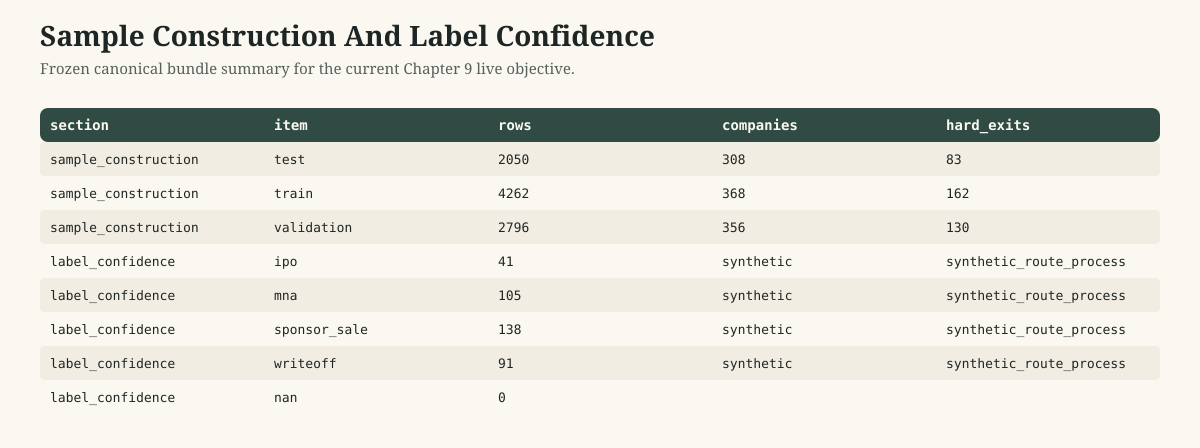

**ch09_vcpe_fig2_main_evaluation_table.svg**

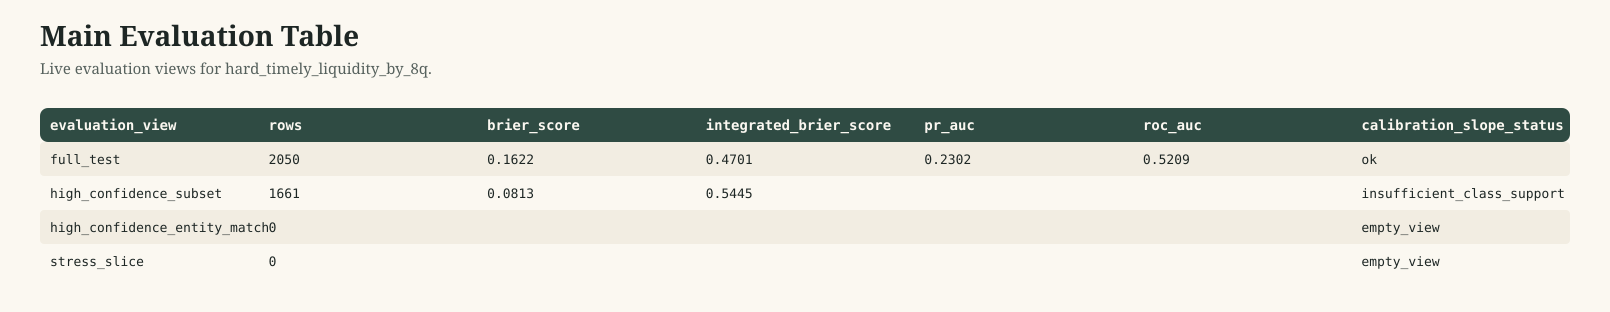

**ch09_vcpe_fig3_universe_sector_stage_heterogeneity.svg**

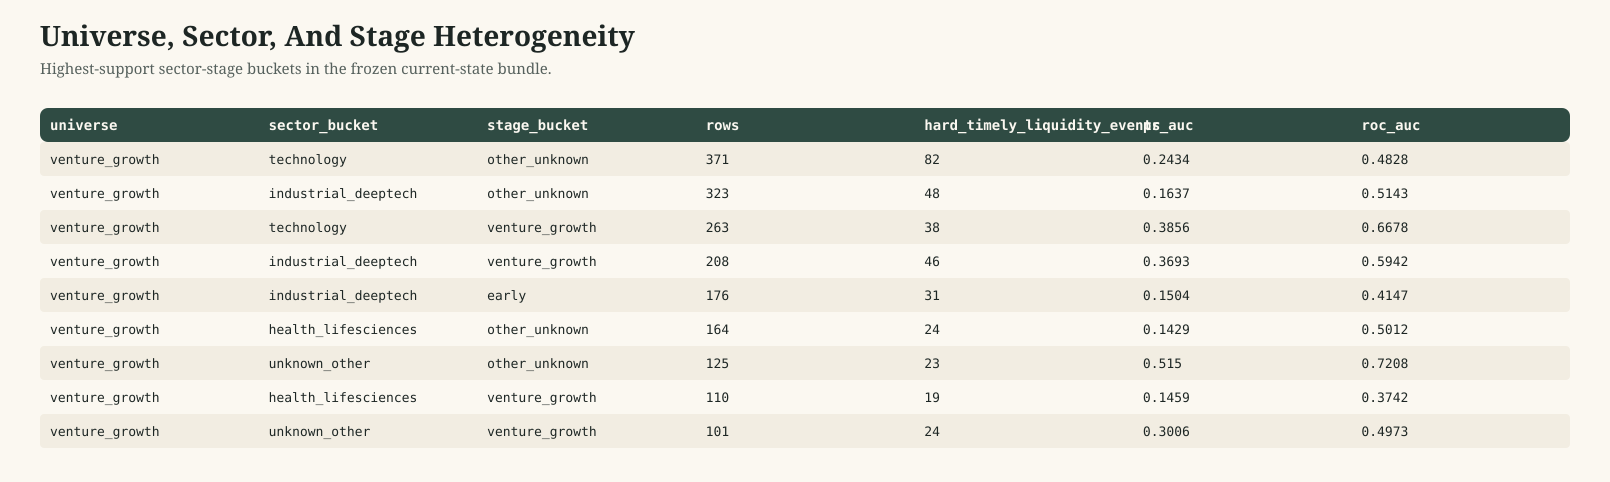

**ch09_vcpe_fig4_hard_timely_liquidity_calibration.svg**

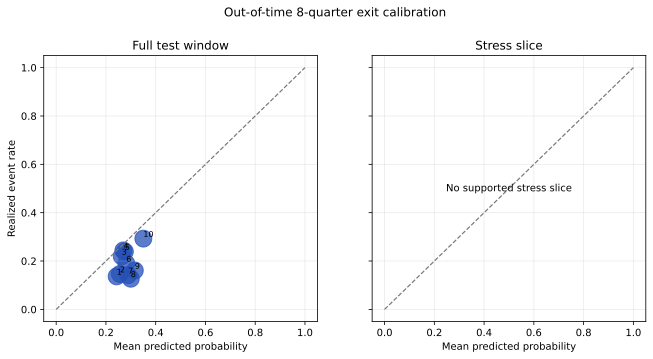

In [3]:
show_first_table([
    OUTPUT_DIR / "decision_summary.csv",
    OUTPUT_DIR / "headline_summary.csv",
    OUTPUT_DIR / "model_performance.csv",
    OUTPUT_DIR / "route_summary.csv",
])
show_note(OUTPUT_DIR / "run_summary.md")
show_figures(OUTPUT_DIR)


## Optional Licensed Reproduction

The private Paper 7 package has its own notebook under `third_party_reproduction/notebooks`. Keep licensed rows outside `repo/`.


In [4]:
RUN_LIVE = False
LIVE_DATA_DIR = Path(os.environ.get("BOOK2_PE_VC_HAZARD_LIVE_DATA_DIR", ""))
LIVE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_live"

if RUN_LIVE:
    if not LIVE_DATA_DIR.exists():
        raise FileNotFoundError("Set LIVE_DATA_DIR or BOOK2_PE_VC_HAZARD_LIVE_DATA_DIR before running live mode.")
    run_command([
        sys.executable,
        PROJECT_ROOT / "python" / "run_vc_pe_exit_prediction.py",
        "--data-mode",
        "live",
        "--live-data-dir",
        LIVE_DATA_DIR,
        "--outdir",
        LIVE_OUTPUT_DIR,
    ], cwd=PROJECT_ROOT)
else:
    print("Live run skipped. Public sample output above is the default notebook path.")


Live run skipped. Public sample output above is the default notebook path.
